# Parte 1


In [1]:
# Importa las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat 

# Carga y Limpieza de Datos 🔄

Antes de sumergirnos en el análisis de datos, es esencial preparar nuestros datos para asegurarnos de que están limpios y listos para un procesamiento más profundo. En esta sección, nos centraremos en tres tareas clave:

## Importación de Datos 📂
Comenzaremos importando los datos del ENCOVI utilizando la biblioteca `pandas` y pyreadstat, la cual es una herramienta poderosa para la manipulación de datos en Python.

## Tratamiento de Valores Faltantes ❓
Es común encontrar valores faltantes en un conjunto de datos. Estos pueden ser el resultado de errores en la recopilación de datos o simplemente casos donde no se aplicaba una determinada medición. Identificaremos estos valores faltantes y aplicaremos estrategias para tratarlos, como llenarlos con la media o mediana, o descartarlos si es necesario.

## Normalización de Nombres de Columnas 📛
Para facilitar el manejo de los datos, normalizaremos los nombres de las columnas para que sigan un estándar coherente, como minúsculas y sin espacios o caracteres especiales. Esto nos ayudará a evitar errores comunes al referirnos a estas columnas en análisis posteriores.



In [2]:
# Ajustes para visualización de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# -------------------------
# Carga y Limpieza de Datos
# -------------------------

# Carga los conjuntos de datos desde archivos .sav
hogares, meta_hogares = pyreadstat.read_sav('ENCOVI_Hogar.sav')
personas, meta_personas = pyreadstat.read_sav('ENCOVI_Personas.sav')

In [3]:

# Visualiza las primeras filas para entender la estructura
print(hogares.head())
print(personas.head())

# Identifica valores faltantes
print(hogares.isnull().sum())
print(personas.isnull().sum())

   REGION  DEPTO  AREA  UPM  NUMHOG  FACTOR  FACTOR3  POBREZA  THOGAR  PPB01  PPB02  PPB03  PPB04  PPD04  PPD04A  PPD04B  PPD04C  PPD06  PPD07  PPD08  PPA11A  PPA11B  P01A01  P01A02  P01A03  P01A04  P01A05A  P01A05B  P01A05C  P01A05D  P01A05E  P01A05F  P01A06  P01B01  P01B02  P01B03  P01C01  P01C02A  P01C02B  P01C02C  P01C02D  P01C02E  P01C02F  P01C02G  P01C02H  P01C02I  P01C02J  P01C02K  P01C02L  P01C02M  P01C03A  P01C03B  P01C03C  P01C03D  P01C03E   P01C04  P01D01  P01D02  P01D03  P01D04  P01D05  P01D06  P01D07  P01D08  P01D09  P01D10  P01D11  P01D12  P01D13A  P01D13B  P01D14  P01D15A  P01D15B  P01D16  P01D17  P01D18  P01D19A  P01D19B  P01D19C  P01D19D  P01D20A  P01D20B  P01D20C  P01D20D  P01D21  P01D22A  P01D22B  P01D23A  P01D24  P01D25  P01D26  P01D27  P01D28  P01D29A  P01D29B  P01D29C  P01D30  P01D31  ID_FUENTES_1  P01E01_1  P01E02_1 UNIDAD_FUENTES_1  P01E03_1  ID_FUENTES_2  P01E01_2  P01E02_2 UNIDAD_FUENTES_2  P01E03_2  ID_FUENTES_3  P01E01_3  P01E02_3 UNIDAD_FUENTES_3  \
0     1

In [4]:
hogares.fillna(hogares.mean(), inplace=True)
personas.fillna(personas.mean(), inplace=True)

# Normaliza los nombres de columnas
hogares.columns = [col.lower().replace(' ', '_') for col in hogares.columns]
personas.columns = [col.lower().replace(' ', '_') for col in personas.columns]


C:\Users\rober\AppData\Local\Temp\ipykernel_35084\693963856.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  hogares.fillna(hogares.mean(), inplace=True)
C:\Users\rober\AppData\Local\Temp\ipykernel_35084\693963856.py:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  personas.fillna(personas.mean(), inplace=True)


# Análisis Univariable 📊

Una vez que nuestros datos están limpios y preparados, podemos empezar a explorarlos individualmente. En el análisis univariable, examinamos una sola variable (columna) a la vez. Esto nos puede ayudar a entender la distribución y tendencias centrales de los datos en cuestión. En esta etapa, nos enfocaremos en:

## Estadísticas Descriptivas 📈
Calcularemos medidas de tendencia central como la media, mediana y moda para cada variable numérica. Esto nos dará una idea de la distribución general y los valores típicos en nuestro conjunto de datos.

## Visualización de Distribuciones 🎨
Usaremos visualizaciones como histogramas y boxplots para ver la distribución de los datos. Esto puede revelar la presencia de outliers, sesgos en los datos, y si se aproximan a una distribución normal.

A continuación, examinaremos nuestras variables más importantes mediante estas técnicas.



             region         depto         area           upm        numhog        factor       factor3       pobreza        thogar         ppb01         ppb02         ppb03         ppb04         ppd04        ppd04a        ppd04b        ppd04c         ppd06         ppd07         ppd08        ppa11a        ppa11b        p01a01        p01a02        p01a03        p01a04       p01a05a       p01a05b       p01a05c       p01a05d      p01a05e       p01a05f        p01a06        p01b01        p01b02        p01b03        p01c01       p01c02a       p01c02b       p01c02c       p01c02d       p01c02e       p01c02f       p01c02g       p01c02h       p01c02i       p01c02j       p01c02k       p01c02l       p01c02m       p01c03a       p01c03b       p01c03c       p01c03d       p01c03e         p01c04       p01d01        p01d02        p01d03        p01d04        p01d05        p01d06        p01d07        p01d08        p01d09        p01d10        p01d11        p01d12       p01d13a       p01d13b        p01d14  \

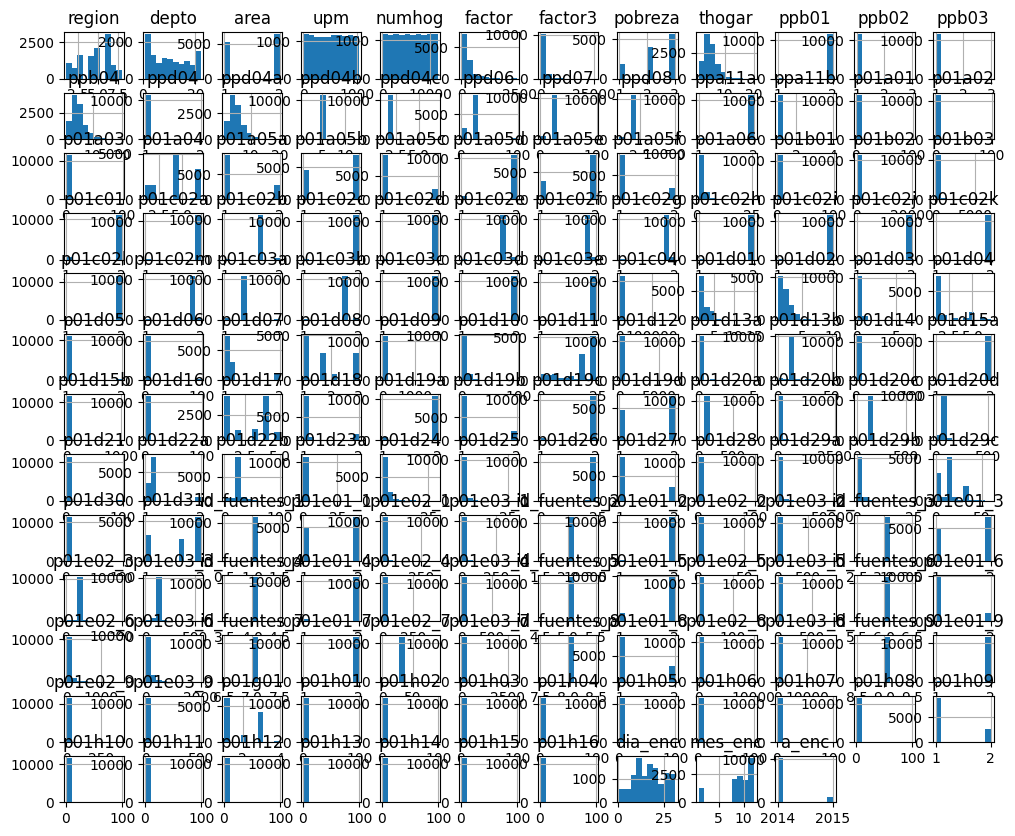

ValueError: Layout of 5x5 must be larger than required size 154

<Figure size 1200x1000 with 0 Axes>

In [ ]:
# Estadísticas descriptivas
print(hogares.describe())
print(personas.describe())

# Histogramas
hogares.hist(figsize=(12, 10))
plt.show()

# Boxplots
hogares.plot(kind='box', subplots=True, layout=(5,5), figsize=(12, 10))
plt.show()


Count: Cada columna tiene la misma cantidad de observaciones (11,536), lo que sugiere que no hay valores faltantes en los datos recopilados.

Mean y STD (Desviación Estándar): Los valores promedio y las desviaciones estándar varían significativamente entre las columnas. Por ejemplo, la columna region tiene una media de 4.599515 con una desviación estándar de 1.890770, lo que indica una variación moderada en la región de los hogares.

Mínimos y Máximos: Los valores mínimos y máximos indican el rango de datos, que podría usarse para identificar valores atípicos o errores en los datos. Por ejemplo, si la region representa una clasificación con un número esperado de regiones, cualquier valor fuera de ese rango podría ser un error.

Medianas (50% Percentil): Las medianas pueden ofrecer una mejor comprensión de la distribución de los datos, ya que no son tan sensibles a los valores atípicos como las medias.

Count: Al igual que con los datos de hogares, hay 11,536 observaciones en cada columna para el conjunto de datos de personas, lo que indica que no hay valores faltantes.

Mean y STD (Desviación Estándar): Los valores promedio y las desviaciones estándar indican la variabilidad de los datos. Por ejemplo, la variable p01b02 tiene un promedio cercano a 584 con una desviación estándar alta de aproximadamente 589, lo que podría sugerir una gran variabilidad en esta medida.

Mínimos y Máximos: Similar a los datos de hogares, los mínimos y máximos pueden ayudar a identificar valores atípicos o errores en el conjunto de datos de personas.

Medianas (50% Percentil): Las medianas pueden ofrecer una mejor comprensión de la tendencia central para los datos de personas, minimizando la influencia de valores atípicos.

# Análisis Bivariable 🔄📊

El siguiente paso en nuestro viaje de EDA es mirar las relaciones entre pares de variables. Esto se conoce como análisis bivariable y puede revelar correlaciones y tendencias que no son evidentes en el análisis univariable.

## Correlaciones 🔍
Exploraremos cómo las variables en nuestro conjunto de datos se relacionan entre sí. Para esto, calcularemos el coeficiente de correlación, el cual mide la fuerza y dirección de la relación entre dos variables.

## Scatter Plots 📉
Los gráficos de dispersión (scatter plots) son una herramienta excelente para visualizar estas correlaciones. Nos permiten ver cómo cambia una variable en respuesta a otra y si esta relación parece ser fuerte o débil.

Procederemos a analizar algunas de las relaciones más significativas visualmente.



In [ ]:
# Scatterplot:

sns.scatterplot(data=hogares)

<AxesSubplot: >

Error in callback <function _draw_all_if_interactive at 0x000001CC9B7AA170> (for post_execute):


KeyboardInterrupt: 

c:\Users\rober\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


/var/folders/vf/44lz8h455mvflsvv9khsdx5w0000gn/T/ipykernel_2496/164784494.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_hogares = hogares.corr()


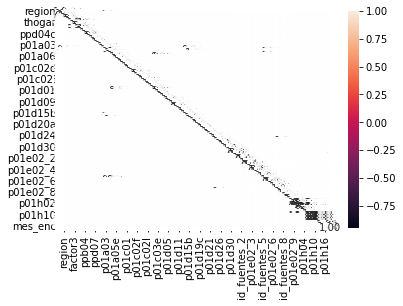

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x29dc5e050> (for post_execute):


KeyboardInterrupt: 

In [ ]:
# Correlación entre variables
corr_hogares = hogares.corr()
sns.heatmap(corr_hogares, annot=True, fmt=".2f")
plt.show()




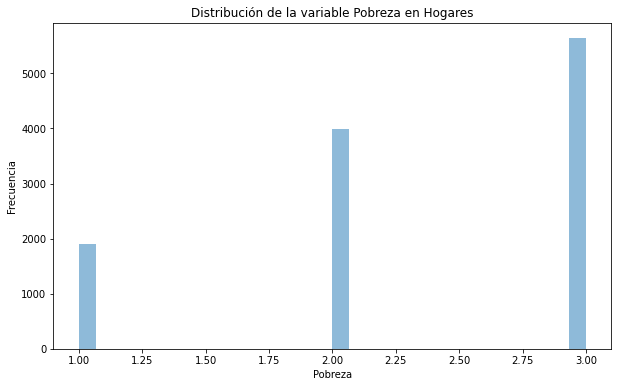

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(hogares['pobreza'], bins=30, alpha=0.5)
plt.title('Distribución de la variable Pobreza en Hogares')
plt.xlabel('Pobreza')
plt.ylabel('Frecuencia')
plt.show()

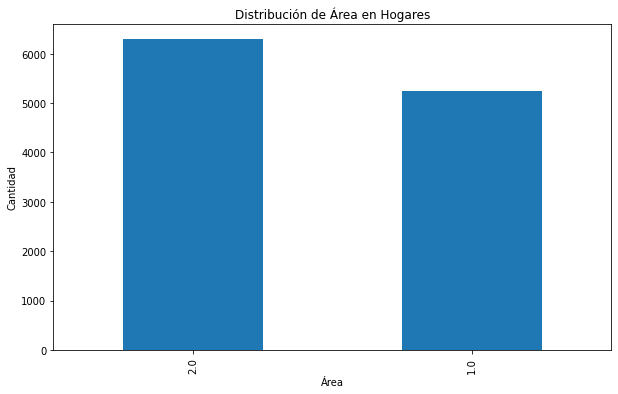

In [ ]:
area_counts = hogares['area'].value_counts()
plt.figure(figsize=(10,6))
area_counts.plot(kind='bar')
plt.title('Distribución de Área en Hogares')
plt.xlabel('Área')
plt.ylabel('Cantidad')
plt.show()

Text(0.5, 1.0, 'Distribución de Área en Hogares')

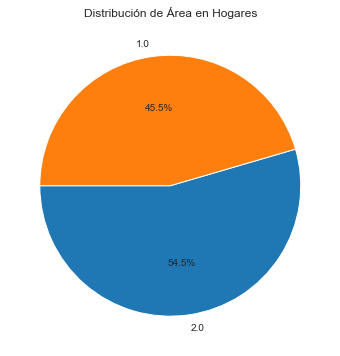

In [ ]:
# Gráfico de pie

sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
plt.pie(area_counts, labels=area_counts.index, autopct='%1.1f%%', startangle=180)
plt.title('Distribución de Área en Hogares')

# Parte 2

In [41]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, GaussianDropout
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, PReLU, ELU
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.utils import to_categorical

from keras.layers import Activation
import math

scaler = StandardScaler()
X = hogares[['depto', 'region','area','p01a01','p01a02', 'p01a03', 'p01a04', 'p01a05a', 'p01a05b', 'p01a05c', 'p01a05d', 'p01a05e', 'p01b01', 'p01b02', 'p01b03', 'p01d04', 'p01d05', 'p01d06', 'p01d07', 'p01d08', 'p01d09', 'p01d10', 'p01d11', 'p01d12', 'p01d13a', 'p01d13b', 'p01d21', 'p01d22a', 'p01d22b', 'p01d23a', 'p01d24', 'p01d25', 'p01d26', 'p01d27', 'p01d28', 'p01d29a', 'p01d29b', 'p01d29c', 'p01d30', 'p01d31', 'p01h01', 'p01g01', 'p01h02', 'p01h03', 'p01h04', 'p01h05', 'p01h06', 'p01h07', 'p01h08', 'p01h09', 'p01h10', 'p01h11', 'p01h12', 'p01h13', 'p01h14', 'p01h15', 'p01h16']]

y = hogares[['pobreza']].astype(int) 
encoder = LabelEncoder()
encoder.fit(y)
encoded_Y = encoder.transform(y)

y = to_categorical(y -1)  # Subtract 1 to make class labels 0-based

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from keras.utils import to_categorical
print(y_test)


[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


c:\Users\rober\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:99: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\rober\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_label.py:134: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [52]:


# Build a neural network model
model = Sequential()

# Input layer with the same number of neurons as features
model.add(Dense(256, input_shape=(X.shape[1],), activation='relu'))

# Hidden layers (customize as needed)
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))


# Output layer with three neurons (for 3 classes) and softmax activation
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [53]:

history1 = model.fit(X_train, y_train, epochs=50, batch_size=10, validation_split=0.25, verbose=2)

print("Perdida de entrenamiento del modelo 1:" + str({history1.history['loss'][-1]}) + "\n")
loss1 = model.evaluate(X_test, y_test)
print("Perdida de prueba del modelo 1:" + str(loss1))

Epoch 1/50
693/693 - 2s - loss: 2.1985 - accuracy: 0.4898 - val_loss: 1.3731 - val_accuracy: 0.5037 - 2s/epoch - 3ms/step
Epoch 2/50
693/693 - 1s - loss: 1.1227 - accuracy: 0.5326 - val_loss: 0.9180 - val_accuracy: 0.5488 - 948ms/epoch - 1ms/step
Epoch 3/50
693/693 - 1s - loss: 0.8923 - accuracy: 0.5547 - val_loss: 0.9163 - val_accuracy: 0.5483 - 873ms/epoch - 1ms/step
Epoch 4/50
693/693 - 1s - loss: 0.8816 - accuracy: 0.5600 - val_loss: 0.8446 - val_accuracy: 0.5834 - 812ms/epoch - 1ms/step
Epoch 5/50
693/693 - 1s - loss: 0.8694 - accuracy: 0.5657 - val_loss: 0.8553 - val_accuracy: 0.5839 - 814ms/epoch - 1ms/step
Epoch 6/50
693/693 - 1s - loss: 0.8579 - accuracy: 0.5722 - val_loss: 0.8378 - val_accuracy: 0.5938 - 802ms/epoch - 1ms/step
Epoch 7/50
693/693 - 1s - loss: 0.8618 - accuracy: 0.5742 - val_loss: 0.8451 - val_accuracy: 0.5847 - 807ms/epoch - 1ms/step
Epoch 8/50
693/693 - 1s - loss: 0.8584 - accuracy: 0.5704 - val_loss: 0.8423 - val_accuracy: 0.5795 - 808ms/epoch - 1ms/step
Epo

In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred = model.predict(X_test)
# Evaluación del modelo con el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

# Calculo de precision
y_pred = np.argmax(y_pred, axis=1)
y_testing = np.argmax(y_test, axis=1)
print(y_pred)
print(y_testing)
print("Accuracy ", accuracy_score(np.argmax(y_test, axis=1), y_pred,))
print("F1-score: ", f1_score(np.argmax(y_test, axis=1), y_pred, average="macro"))

73/73 [==============================] - 0s 972us/step
73/73 - 0s - loss: 0.7826 - accuracy: 0.6187 - 75ms/epoch - 1ms/step

Test accuracy: 0.6187174916267395
[2 2 1 ... 1 2 1]
[2 2 2 ... 0 1 0]
Accuracy  0.6187175043327556
F1-score:  0.5295887766448223


# Parte 3

## Reflexión:

El proceso de familiarización con el Análisis Exploratorio de Datos (EDA) y el desarrollo de modelos de aprendizaje automático es una travesía que no sólo mejora nuestras habilidades técnicas, sino que también amplía nuestra visión sobre la resolución de problemas. Al comenzar a trabajar con el conjunto de datos de la "Encuesta Nacional de Condiciones de Vida 2014" (ENCOVI) de Guatemala, nos enfrentamos a un desafío inicial con los archivos en formato .sav. Estos archivos, típicos de software estadístico como SPSS, no eran inmediatamente accesibles con las herramientas estándar de Python como pandas.

La solución a este problema llegó con la biblioteca pyreadstat, la cual permitió la lectura de estos archivos .sav directamente en Python, posibilitando así la manipulación y análisis de los datos. Este pequeño triunfo inicial fue emblemático del tipo de aprendizaje práctico y adaptativo necesario en la ciencia de datos.

ChatGPT emergió como una herramienta esencial en este proceso. A diferencia de las búsquedas estáticas en Google o las consultas en foros como Stack Overflow, donde la interacción es unidireccional y pasiva, ChatGPT ofreció una experiencia dinámica e interactiva. Como una amalgama de tutor y colaborador, ChatGPT proporcionó clarificaciones inmediatas, ejemplos de código y una guía paso a paso que facilitó el aprendizaje y la aplicación de las bibliotecas de Python. Con su ayuda, fue posible superar los obstáculos técnicos y comprender mejor las complejidades del análisis de datos.

La integración de ChatGPT como una herramienta en nuestro arsenal resalta el potencial sinérgico de la inteligencia artificial y la habilidad humana. No solo optimiza nuestro trabajo, reduciendo la carga de buscar y filtrar a través de la vasta información en línea, sino que también se postula como una compañía constante para la exploración y aprendizaje continuo.

Reflexionando sobre el propósito del laboratorio, que era familiarizarse con el EDA y el aprendizaje automático, es claro que los objetivos se alinearon con los retos encontrados y las soluciones aplicadas. El manejo de datos reales, con sus inherentes complicaciones, proporcionó una plataforma sólida para entender la importancia y la aplicabilidad de estas habilidades en el mundo profesional, en especial en el ámbito de la ciencia de datos.

Las lecciones aprendidas en este proceso van más allá de la mera ejecución de código; abarcan la comprensión de que cada conjunto de datos tiene su propia historia y peculiaridades. La capacidad de adaptar nuestro enfoque y herramientas es invaluable y, en este sentido, la ciencia de datos se revela como una disciplina de aprendizaje y adaptación constantes.

En términos profesionales, estas habilidades abren puertas a un entendimiento más profundo de la información, permitiendo que uno se convierta no solo en un intérprete de datos, sino también en un narrador de historias basadas en datos. La ciencia de datos, después de todo, es una herramienta poderosa para la toma de decisiones informadas, la identificación de tendencias y patrones, y la resolución de problemas reales, lo que en el contexto de un país como Guatemala, puede ser particularmente transformador en áreas como el desarrollo económico y social.

